In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

In [2]:
print("=" * 50)
print("МИНИ-ПРОЕКТ: Распознавание рукописных цифр")
print("=" * 50)
print("\nЗадача: классификация черно-белых изображений рукописных цифр от 0 до 9.")
print("Классы: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9")
print("Источник данных: MNIST (70 000 изображений 28x28 пикселей)")

МИНИ-ПРОЕКТ: Распознавание рукописных цифр

Задача: классификация черно-белых изображений рукописных цифр от 0 до 9.
Классы: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
Источник данных: MNIST (70 000 изображений 28x28 пикселей)


**Датасет:** MNIST (Mixed National Institute of Standards and Technology)

- **Количество изображений:** 70000
- **Размер каждого изображения:** 28x28 пикселей
- **Цветность:** черно-белое (1 канал)
- **Количество классов:** 10 (цифры от 0 до 9)
- **Разделение по умолчанию:** 60000 train / 10000 test

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # нормализация для MNIST
])

In [6]:
full_trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print("Данные загружены!")

100%|██████████| 9.91M/9.91M [00:00<00:00, 22.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 601kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.68MB/s]

Данные загружены!


In [7]:
train_size = int(0.7 * len(full_trainset))
val_size = len(full_trainset) - train_size
trainset, valset = random_split(full_trainset, [train_size, val_size])

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
valloader = DataLoader(valset, batch_size=64, shuffle=False)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

print(f"Размер обучающей выборки (train): {len(trainset)}")
print(f"Размер валидационной выборки (validation): {len(valset)}")
print(f"Размер тестовой выборки (test): {len(testset)}")

Размер обучающей выборки (train): 42000
Размер валидационной выборки (validation): 18000
Размер тестовой выборки (test): 10000


## Выбор модели

**Тип модели:** MLP

**Архитектура:**
- Входной слой: 784 нейрона (28×28)
- Скрытый слой 1: 128 нейронов + ReLU + Dropout(0.2)
- Скрытый слой 2: 64 нейрона + ReLU + Dropout(0.2)
- Выходной слой: 10 нейронов (классы)

**Обоснование:** MLP- простейшая нейросеть, подходит для решения задачи классификации MNIST.

In [8]:
class SimpleMLP(nn.Module):
    def __init__(self):
        super(SimpleMLP, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleMLP().to(device)

print(f"Используем устройство: {device}")
print("\nАрхитектура модели:")
print(model)

Используем устройство: cpu

Архитектура модели:
SimpleMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
)


In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Функция потерь: CrossEntropyLoss")
print("Оптимизатор: Adam (learning rate = 0.001)")

Функция потерь: CrossEntropyLoss
Оптимизатор: Adam (learning rate = 0.001)


In [10]:
epochs = 10
train_losses = []
val_losses = []
val_accuracies = []

print("\nНачинаем обучение...")
print("-" * 60)

for epoch in range(epochs):
    # Обучение
    model.train()
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(trainloader)
    train_losses.append(train_loss)

    # Валидация
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(valloader)
    val_accuracy = 100 * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Эпоха {epoch+1:2d}: Train Loss = {train_loss:.4f} | Val Loss = {val_loss:.4f} | Val Acc = {val_accuracy:.2f}%")

print("-" * 60)
print("Обучение завершено!")


Начинаем обучение...
------------------------------------------------------------
Эпоха  1: Train Loss = 0.4038 | Val Loss = 0.1707 | Val Acc = 94.83%
Эпоха  2: Train Loss = 0.1938 | Val Loss = 0.1265 | Val Acc = 96.09%
Эпоха  3: Train Loss = 0.1482 | Val Loss = 0.1057 | Val Acc = 96.66%
Эпоха  4: Train Loss = 0.1245 | Val Loss = 0.0982 | Val Acc = 97.14%
Эпоха  5: Train Loss = 0.1094 | Val Loss = 0.1007 | Val Acc = 97.04%
Эпоха  6: Train Loss = 0.0981 | Val Loss = 0.1015 | Val Acc = 97.08%
Эпоха  7: Train Loss = 0.0912 | Val Loss = 0.0909 | Val Acc = 97.34%
Эпоха  8: Train Loss = 0.0816 | Val Loss = 0.0972 | Val Acc = 97.17%
Эпоха  9: Train Loss = 0.0771 | Val Loss = 0.0860 | Val Acc = 97.53%
Эпоха 10: Train Loss = 0.0711 | Val Loss = 0.0891 | Val Acc = 97.45%
------------------------------------------------------------
Обучение завершено!


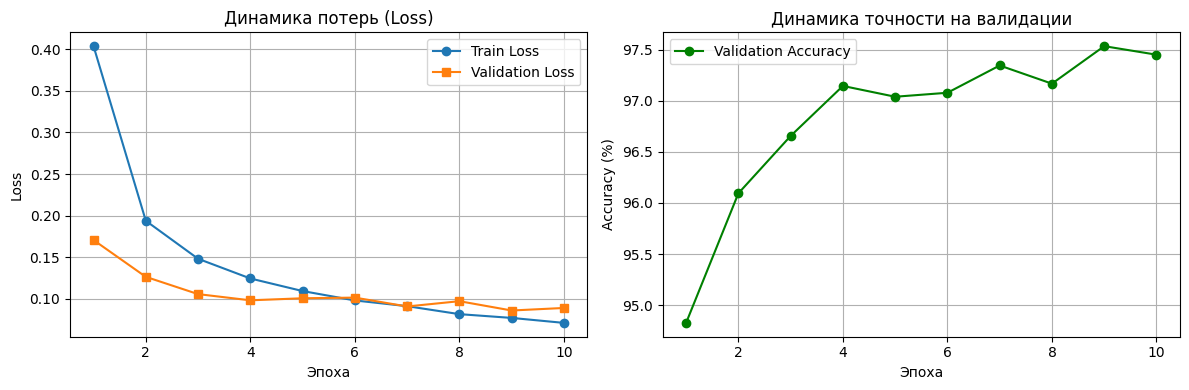

In [11]:
plt.figure(figsize=(12, 4))

# График потерь
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs+1), train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs+1), val_losses, label='Validation Loss', marker='s')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Динамика потерь (Loss)')
plt.legend()
plt.grid(True)

# График точности
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs+1), val_accuracies, label='Validation Accuracy', marker='o', color='green')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy (%)')
plt.title('Динамика точности на валидации')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"\nТочность на тестовой выборке: {100 * correct / total:.2f}%")


Точность на тестовой выборке: 97.42%


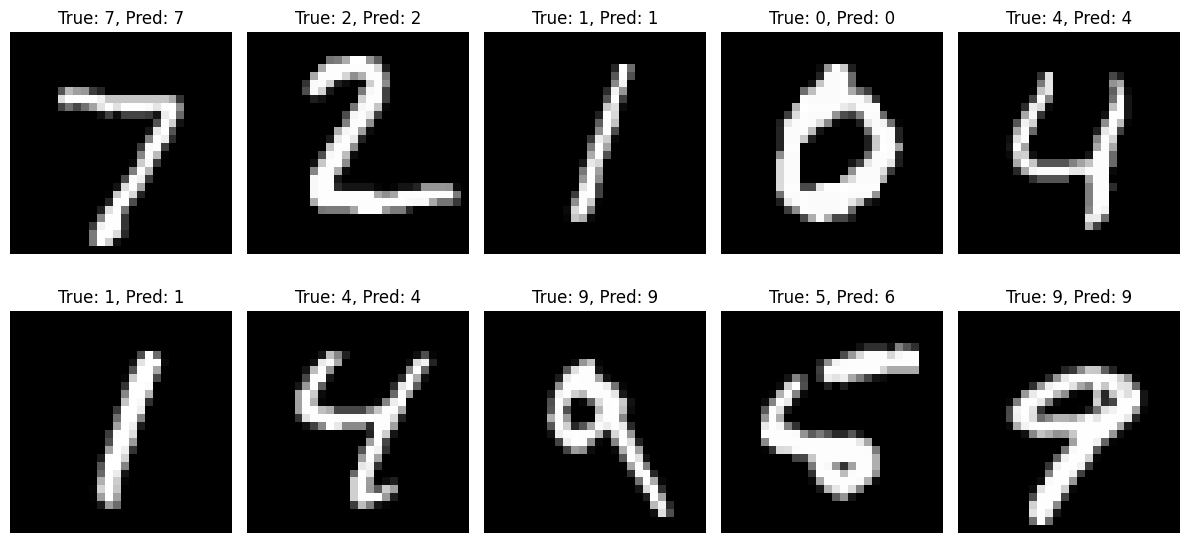

In [13]:
dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = torch.max(outputs, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 6))
axes = axes.ravel()

for i in range(10):
    img = images[i].cpu().squeeze()
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'True: {labels[i]}, Pred: {predicted[i]}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Выводы

1. **Модель:** MLP обучена с нуля на датасете MNIST.
2. **Данные:** Разделены на train (70%), validation (30%) и test.
3. **Результат:** Итоговая точность на тестовой выборке составляет- 97%.
4. **Графики:** Loss на train и validation снижаются, точность растёт- переобучения нет.